# DQN Highway — Episode Visualisation
**Before vs After Training**

This notebook loads a saved checkpoint and renders full episodes as frame-by-frame animations.
- **Untrained agent**: random weights (ε = 1.0, pure random)
- **Trained agent**: loaded from `dqn_highway_checkpoint.pt` (ε = 0, greedy)


## 0 — Setup

In [15]:
import sys, os, random
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display
import torch
import torch.nn as nn
import gymnasium as gym
import highway_env


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


c:\Users\arfib\anaconda3\envs\RL_env\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Device: cpu


## 1 — Environment Config

In [16]:
SHARED_CORE_ENV_ID = "highway-v0"

SHARED_CORE_CONFIG = {
    "observation": {
        "type": "Kinematics",
        "vehicles_count": 10,
        "features": ["presence", "x", "y", "vx", "vy"],
        "absolute": False,
        "normalize": True,
        "clip": True,
        "see_behind": True,
        "observe_intentions": False,
    },
    "action": {
        "type": "DiscreteMetaAction",
        "target_speeds": [20, 25, 30],
    },
    "lanes_count": 4,
    "vehicles_count": 45,
    "controlled_vehicles": 1,
    "initial_lane_id": None,
    "duration": 60,
    "ego_spacing": 2,
    "vehicles_density": 1.0,
    "collision_reward": -1.5,
    "right_lane_reward": 0.0,
    "high_speed_reward": 0.7,
    "lane_change_reward": -0.02,
    "reward_speed_range": [22, 30],
    "normalize_reward": True,
    "offroad_terminal": True,
    # render config
    "screen_width": 800,
    "screen_height": 200,
    "centering_position": [0.3, 0.5],
    "scaling": 6,
    "show_trajectories": False,
}

def make_env(config=None, render_mode="rgb_array"):
    env = gym.make(SHARED_CORE_ENV_ID, render_mode=render_mode)
    if config:
        env.unwrapped.config.update(config)
    return env

# Quick check
env_tmp = make_env(SHARED_CORE_CONFIG)
obs, _ = env_tmp.reset()
OBS_SIZE  = obs.flatten().shape[0]
N_ACTIONS = env_tmp.action_space.n
env_tmp.close()
print(f"OBS_SIZE={OBS_SIZE}, N_ACTIONS={N_ACTIONS}")


OBS_SIZE=50, N_ACTIONS=5


## 2 — Model Architecture

In [20]:
class QNet(nn.Module):
    def __init__(self, obs_size, n_actions, hidden_size=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions),
        )

    def forward(self, x):
        return self.net(x)

def greedy_action(q_net, obs, device):
    """Pick the greedy action from a QNet given a numpy obs."""
    state_t = torch.FloatTensor(obs.flatten()).unsqueeze(0).to(device)
    with torch.no_grad():
        q_values = q_net(state_t)
    return q_values.argmax(dim=1).item()


## 3 — Load Checkpoint

In [21]:
CHECKPOINT_PATH = "dqn_highway_checkpoint.pt"  # adjust if needed

# Trained agent
trained_net = QNet(OBS_SIZE, N_ACTIONS).to(device)
trained_net.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
trained_net.eval()
print("Trained checkpoint loaded.")

# Untrained agent — fresh random weights
untrained_net = QNet(OBS_SIZE, N_ACTIONS).to(device)
untrained_net.eval()
print("Untrained network initialised (random weights).")


Trained checkpoint loaded.
Untrained network initialised (random weights).


## 4 — Rollout Helper

In [22]:
ACTION_LABELS = {0: "LANE_LEFT", 1: "IDLE", 2: "LANE_RIGHT", 3: "FASTER", 4: "SLOWER"}

def run_episode(q_net, config, seed=42, epsilon=0.0, device=device):
    env = make_env(config, render_mode="rgb_array")
    env.reset(seed=seed)
    env.step(env.action_space.sample())
    obs, _ = env.reset(seed=seed)

    def get_frame(env):
        return env.render()

    frames, actions, rewards = [], [], []
    done = False

    while not done:
        action = env.action_space.sample() if random.random() < epsilon else greedy_action(q_net, obs, device)
        print(action)
        obs, r, terminated, truncated, _ = env.step(action)
        frame = get_frame(env)
        if frame is not None:
            frames.append(frame)
            actions.append(action)
            rewards.append(r)
        done = terminated or truncated

    env.close()

    if not frames:
        raise RuntimeError(
            f"All 3 render strategies failed. "
            f"highway_env={highway_env.__version__}. "
            f"Run the diagnostic cell above and share the output."
        )

    return frames, actions, rewards, terminated


## 5 — Run Episodes

In [23]:
SEED = 42  # change to try different traffic scenarios

print("Running UNTRAINED episode...")
frames_before, actions_before, rewards_before, crashed_before = run_episode(
    untrained_net, SHARED_CORE_CONFIG, seed=SEED, epsilon=1.0
)
print(f"  Steps: {len(frames_before)} | Total reward: {sum(rewards_before):.3f} | "
      f"Ended by: {'CRASH' if crashed_before else 'TIMEOUT'}")

print("Running TRAINED episode...")
frames_after, actions_after, rewards_after, crashed_after = run_episode(
    trained_net, SHARED_CORE_CONFIG, seed=SEED, epsilon=0.0
)
print(f"  Steps: {len(frames_after)} | Total reward: {sum(rewards_after):.3f} | "
      f"Ended by: {'CRASH' if crashed_after else 'TIMEOUT'}")


Running UNTRAINED episode...
  Steps: 15 | Total reward: 10.187 | Ended by: CRASH
Running TRAINED episode...
  Steps: 60 | Total reward: 40.909 | Ended by: TIMEOUT


## 6 — Animate Episodes

In [24]:
def make_animation(frames, actions, rewards, title, fps=10):
    """Return an HTML5 video animation."""
    if not frames:
        raise ValueError(f"No frames to animate for '{title}'. Re-run cell 5.")

    fig, ax = plt.subplots(figsize=(10, 2.8))
    ax.axis("off")
    img_obj = ax.imshow(frames[0])

    cumulative = np.cumsum(rewards)
    title_obj = ax.set_title("", fontsize=11)

    def update(i):
        img_obj.set_data(frames[i])
        action_label = ACTION_LABELS.get(actions[i], str(actions[i])) if i < len(actions) else "-"
        title_obj.set_text(
            f"{title}   |   step {i+1}/{len(frames)}   "
            f"|   action: {action_label}   "
            f"|   step_r: {rewards[i]:.3f}   "
            f"|   cum_r: {cumulative[i]:.3f}"
        )
        return img_obj, title_obj

    ani = animation.FuncAnimation(
        fig, update, frames=len(frames), interval=1000 // fps, blit=True
    )
    plt.close(fig)
    return ani


### 6.1 — Untrained Agent (random policy)

In [25]:
ani_before = make_animation(
    frames_before, actions_before, rewards_before,
    title="UNTRAINED (ε=1.0)", fps=10
)
HTML(ani_before.to_jshtml())


### 6.2 — Trained Agent (greedy, ε=0)

In [9]:
ani_after = make_animation(
    frames_after, actions_after, rewards_after,
    title="TRAINED (ε=0)", fps=10
)
HTML(ani_after.to_jshtml())


## 7 — Side-by-Side Comparison

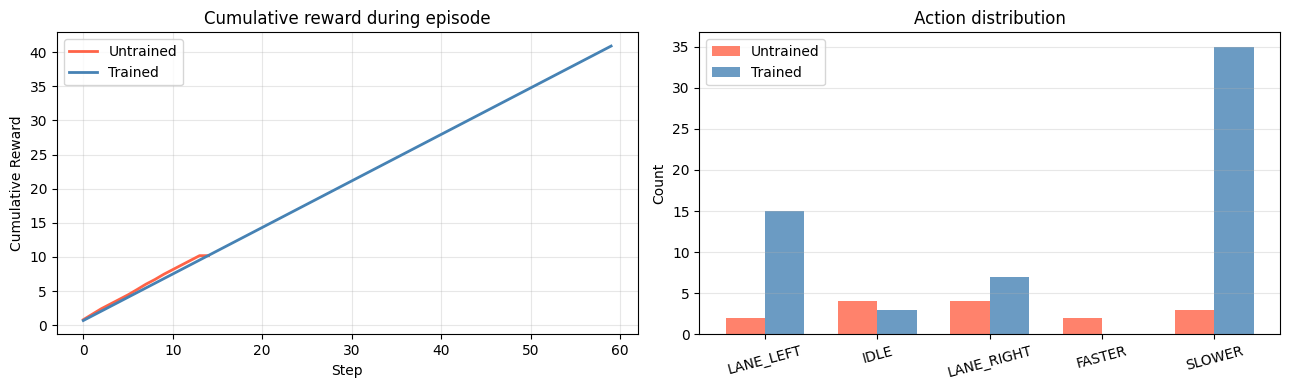

                        Untrained      Trained
----------------------------------------------
Total reward               10.187       40.909
Steps survived                 15           60
Crashed                       YES           NO
Mean step reward            0.679        0.682


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Cumulative reward over time
ax = axes[0]
ax.plot(np.cumsum(rewards_before), color='tomato',    lw=2, label='Untrained')
ax.plot(np.cumsum(rewards_after),  color='steelblue', lw=2, label='Trained')
ax.set_xlabel('Step')
ax.set_ylabel('Cumulative Reward')
ax.set_title('Cumulative reward during episode')
ax.legend()
ax.grid(alpha=0.3)

# Action distributions
ax = axes[1]
n_act = N_ACTIONS
labels = [ACTION_LABELS.get(i, str(i)) for i in range(n_act)]
x = np.arange(n_act)
w = 0.35
counts_before = np.bincount(actions_before, minlength=n_act)
counts_after  = np.bincount(actions_after,  minlength=n_act)
ax.bar(x - w/2, counts_before, w, color='tomato',    alpha=0.8, label='Untrained')
ax.bar(x + w/2, counts_after,  w, color='steelblue', alpha=0.8, label='Trained')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel('Count')
ax.set_title('Action distribution')
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('before_after_comparison.png', dpi=120)
plt.show()

# Summary table
print(f"{'':20} {'Untrained':>12} {'Trained':>12}")
print("-" * 46)
print(f"{'Total reward':<20} {sum(rewards_before):>12.3f} {sum(rewards_after):>12.3f}")
print(f"{'Steps survived':<20} {len(frames_before):>12d} {len(frames_after):>12d}")
print(f"{'Crashed':<20} {'YES' if crashed_before else 'NO':>12} {'YES' if crashed_after else 'NO':>12}")
print(f"{'Mean step reward':<20} {np.mean(rewards_before):>12.3f} {np.mean(rewards_after):>12.3f}")


## 8 — Try Different Seeds

Change `SEED` in cell 5 and re-run cells 5–7 to see different traffic scenarios.
Some useful seeds to try:

| Seed | Scenario notes |
|------|---------------|
| 0    | Light traffic, good for observing lane changes |
| 7    | Dense early traffic, tests reaction time |
| 13   | Forces the agent into a slow-lane situation |
| 42   | Default — balanced traffic |

You can also run the stress test config:


In [ ]:
# Optional: run on denser traffic to stress-test the trained agent
STRESS_CONFIG = {**SHARED_CORE_CONFIG}

print("Running TRAINED agent under STRESS traffic...")
frames_stress, actions_stress, rewards_stress, crashed_stress = run_episode(
    trained_net, STRESS_CONFIG, seed=42, epsilon=0.0
)
print(f"  Steps: {len(frames_stress)} | Total reward: {sum(rewards_stress):.3f} | "
      f"Ended by: {'CRASH' if crashed_stress else 'TIMEOUT'}")

ani_stress = make_animation(
    frames_stress, actions_stress, rewards_stress,
    title="TRAINED — STRESS (density×2)", fps=10
)
HTML(ani_stress.to_jshtml())


Running TRAINED agent under STRESS traffic...
  Steps: 60 | Total reward: 43.548 | Ended by: TIMEOUT


In [ ]:
# Optional: run on denser traffic to stress-test the trained agent
STRESS_CONFIG = {**SHARED_CORE_CONFIG}

print("Running TRAINED agent under STRESS traffic...")
frames_stress, actions_stress, rewards_stress, crashed_stress = run_episode(
    trained_net, STRESS_CONFIG, seed=13, epsilon=0.0
)
print(f"  Steps: {len(frames_stress)} | Total reward: {sum(rewards_stress):.3f} | "
      f"Ended by: {'CRASH' if crashed_stress else 'TIMEOUT'}")

ani_stress = make_animation(
    frames_stress, actions_stress, rewards_stress,
    title="TRAINED — STRESS (density×2)", fps=10
)
HTML(ani_stress.to_jshtml())

Running TRAINED agent under STRESS traffic...
  Steps: 60 | Total reward: 42.917 | Ended by: TIMEOUT
